# Practical 7: Cell–Cell Communication

**Author:** Claudio Novella-Rausell  

In this notebook, we will explore methods to recover **cell–cell communication (CCC)** from spatial transcriptomics data using **TensorCell2Cell**.

TensorCell2Cell leverages **tensor decomposition** to identify *latent communication programs* across multiple contexts — for example, different spatial regions, experimental conditions, or time points.  
Each communication program represents a coordinated pattern of **ligand–receptor interactions** between specific sender and receiver cell types.

To ensure reproducibility and minimize dependency issues, we will use the **LIANA+ integration**, which provides a unified interface to generate CCC scores compatible with TensorCell2Cell.

> ⚠️ **Note:** TensorCell2Cell builds upon the conceptual foundation of methods such as *CellPhoneDB* and others, but extends them by incorporating context variability through tensor decomposition.  
> Links to the original publication and GitHub repository are provided below for reference:

- **GitHub:** [https://github.com/earmingol/cell2cell](https://github.com/earmingol/cell2cell)


In [6]:
import pandas as pd
import scanpy as sc
import plotnine as p9
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import liana as li
import cell2cell as c2c
import decoupler as dc # needed for pathway enrichment
import math
import re

import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

## 0. Read-in data and include metadata

### 🧫 Dataset Overview

In this practical, we will analyze **cell–cell communication (CCC)** patterns using **TensorCell2Cell** applied to a spatial transcriptomics dataset.

We will use a **ADPKD (Autosomal Dominant Polycystic Kidney Disease)** dataset https://journals.lww.com/jasn/abstract/9900/spatial_transcriptomics_reveals_injured_cells,.803.aspx

---

### 🧠 Background

**Autosomal Dominant Polycystic Kidney Disease (ADPKD)** is a genetic disorder characterized by the formation of numerous fluid-filled cysts that progressively replace normal kidney tissue, ultimately leading to renal failure. 

Beyond intrinsic mutations in *PKD1* or *PKD2*, the disease involves a complex **microenvironmental remodeling**, where injured epithelial cells, fibroblasts, immune cells, and endothelial cells engage in aberrant communication.

Recent evidence supports the **“snowball model”** of cystogenesis:

> Once a subset of epithelial cells becomes injured and begins secreting inflammatory and fibrotic mediators, these signals propagate to neighboring cells, amplifying damage and promoting cyst expansion.

In this practical, we will apply **TensorCell2Cell** to uncover communication programs that drive this cascade, focusing on spatial domains and niches within the kidney tissue.

Our specific aims are to:

- Characterize **communication programs** that define the cyst microenvironment.  
- Understand how these programs **vary across layers** of kidney tissue.  
- Identify **ligand–receptor pairs** mediating key pathological interactions.


In [7]:
# load adata
adata = sc.read_h5ad('data/spatial_processed_compressed.h5ad')
adata

AnnData object with n_obs × n_vars = 8149 × 17628
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', 'clusters', 'clusters_0.7', 'S_score', 'G2M_score', 'phase', 'cell_types'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'hb', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_types_colors', 'clusters_colors', 'dendrogram_clusters_0.7', 'hvg', 'leiden', 'library_id_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'LogNorm', 'scaled'
    obsp: 'connectivities', 'distances'

In [8]:
adata.obs['library_id'].value_counts()

library_id
pkd_3      2213
pkd_2      2075
pkd_1      1989
Control    1872
Name: count, dtype: int64

In [9]:
adata.X = adata.layers['LogNorm']

In [10]:
pkd_1 = pd.read_csv("data/pkd_1_cystic_spots.csv", skiprows=1, index_col=0, names=['barcode', 'layer'])
pkd_2 = pd.read_csv("data/pkd_2_cystic_spots.csv", skiprows=1, index_col=0, names=['barcode', 'layer'])
pkd_3 = pd.read_csv("data/pkd_3_cystic_spots.csv", skiprows=1, index_col=0, names=['barcode', 'layer'])
pkd_1['layer'] = pkd_1.layer.str.split('_').str[2]
pkd_2['layer'] = pkd_2.layer.str.split('_').str[2]
pkd_3['layer'] = pkd_3.layer.str.split('_').str[2]
pkd_1.index = pkd_1.index.str.split('-').str[0] + '-1-pkd_1'
pkd_2.index = pkd_2.index.str.split('-').str[0] + '-1-pkd_2'
pkd_3.index = pkd_3.index.str.split('-').str[0] + '-1-pkd_3'

layers = pd.concat([pkd_1,pkd_2,pkd_3])

layers

,layer
barcode,
AAACAGAGCGACTCCT-1-pkd_1,layer1
AAACTCGGTTCGCAAT-1-pkd_1,layer2
AAAGTAGCATTGCTCA-1-pkd_1,layer1
AAATAGCTTAGACTTT-1-pkd_1,layer3
AAATCCGATACACGCC-1-pkd_1,layer1
...,...
TTGTGGTAGGAGGGAT-1-pkd_3,layer2
TTGTGTATGCCACCAA-1-pkd_3,layer1
TTGTGTTTCCCGAAAG-1-pkd_3,layer3


<span style="color:red; font-weight:bold">Task 1: Transfer the layer information to the adata object. How many spots per layer are there? </span>

<details>
<summary>💡 Show solution</summary>
    
```python
adata.obs['layers'] = layers

adata.obs['layers'].value_counts()
```

In [12]:
# TODO


<span style="color:red; font-weight:bold">Task 2: Since we are focusing our analyses in these layers, remove any spots not present in the layers we defined </span>

<details>
<summary>💡 Show solution</summary>
    
```python
adata = adata[adata.obs['layers'].isin(['layer1', 'layer2', 'layer3'])].copy()
```

In [14]:
# TODO


... storing 'layers' as categorical
... storing 'layers' as categorical
... storing 'layers' as categorical


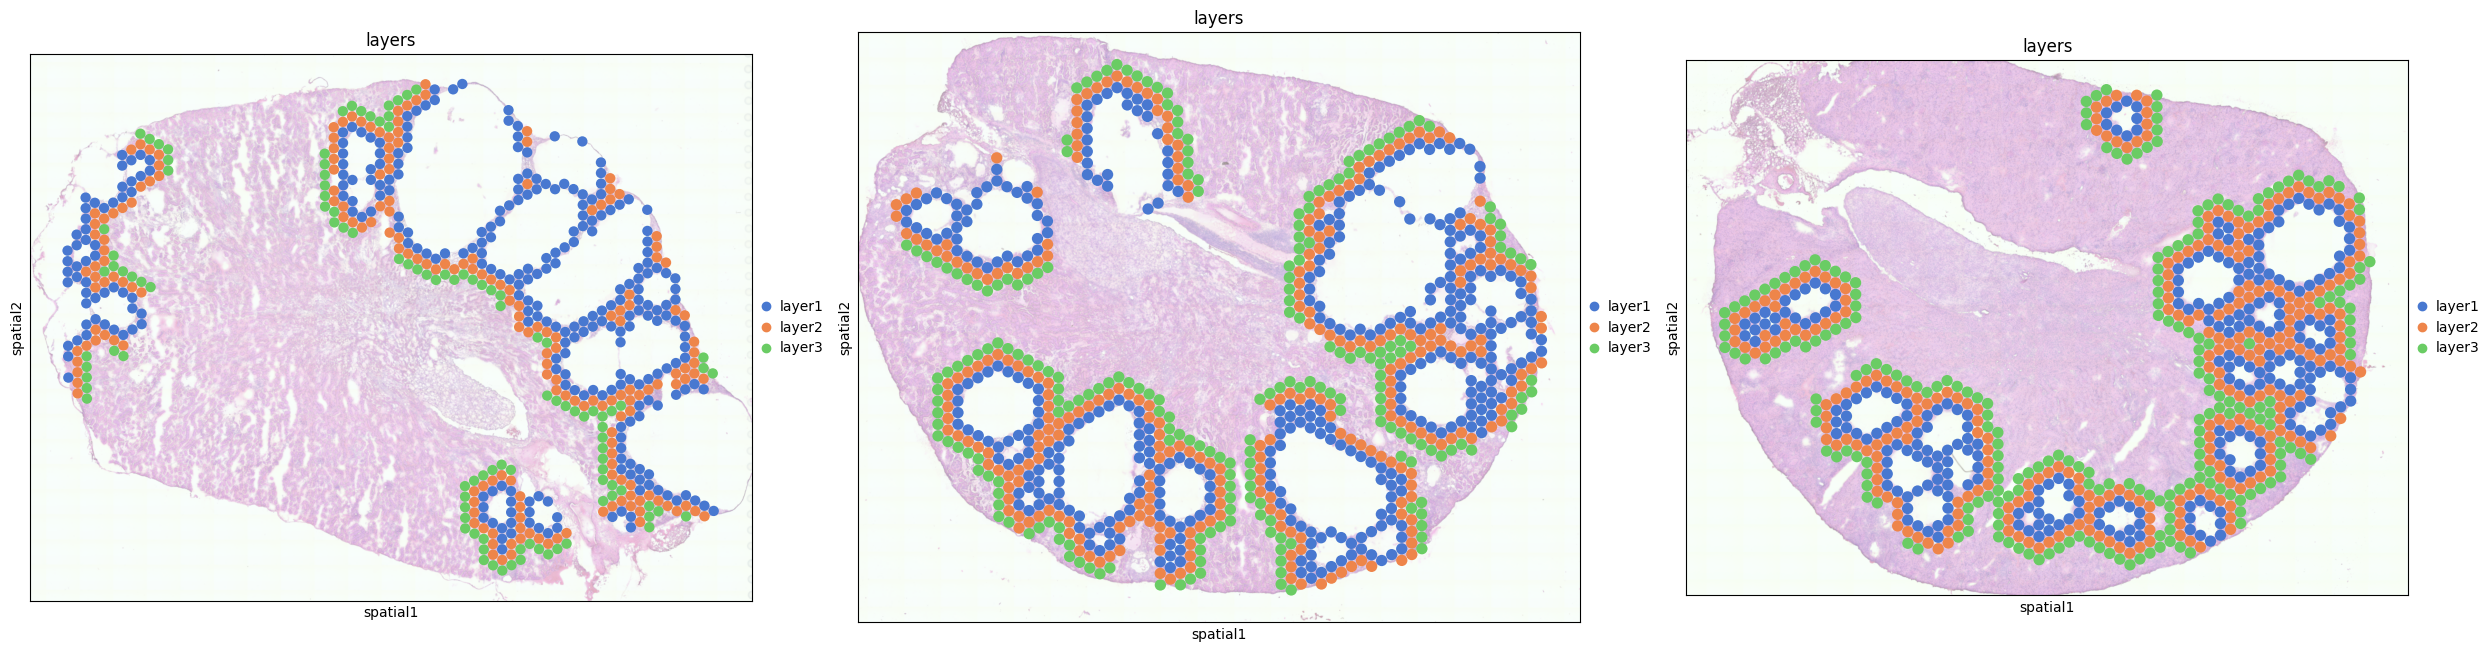

In [15]:
fig, axs = plt.subplots(1,3, figsize=(25, 10))

for i, library in enumerate(
    ["pkd_1", "pkd_2", "pkd_3"]
):
    ad = adata[adata.obs.library_id == library, :].copy()
    
    sc.pl.spatial(
        ad,
        img_key="hires",
        library_id=library,
        color=["layers"],
        size=1.5,
        alpha_img=0.5,
        palette=sns.color_palette("muted"),
        show=False,
        ax=axs[i]
    )
plt.tight_layout()

## 1. Compute CCC scores

To compare cell–cell communication across different layers and kidneys, we first need to define our samples. You can think of these samples as analogous to those in a typical cohort (e.g., 3 controls and 3 disease), except that in this case, the conditions correspond to the different layers, and the replicates are the three kidneys.

<span style="color:red; font-weight:bold">Task 3: Define a metadata column named "sample_context" that includes both the layer and kidney information, separated by an underscore ("_") </span>

<details>
<summary>💡 Show solution</summary>
    
```python
adata.obs['sample_context'] = adata.obs["layers"].astype(str) + "_" + adata.obs["library_id"].astype(str)
```

In [17]:
# TODO


This time around, we will use LIANA+'s rank aggregate to compute communication scores. In short, the rank aggregate is a consensus scoring method that combines results from multiple ligand–receptor inference approaches, producing a unified ranking that reflects the overall strength and consistency of each interaction.

In [18]:
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean
methods = [cellphonedb, cellchat, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [19]:
liana_res = new_rank_aggregate.by_sample(adata,
                                   sample_key='sample_context',
                           groupby='cell_types',
                           resource_name = 'MouseConsensus',
                           expr_prop=0.85, # must be expressed in expr_prop fraction of cells
                           min_cells =1,
                           n_perms = 10,
                           use_raw = False, # run on log- and library-normalized counts
                           verbose = True,
                           inplace = False,
                          )

Converting `sample_context` to categorical!
Now running: layer3_pkd_3: 100%|██████████| 9/9 [01:08<00:00,  7.59s/it]


In [20]:
liana_res

,sample_context,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,lr_probs,cellchat_pvals,lr_gmeans,gmean_pvals,specificity_rank,magnitude_rank
0,layer1_pkd_1,CD-IC,FR-PT + Immune,App,Cd74,2.908977,0.0,0.232190,0.0,2.851462,0.0,0.180318,1.638546e-08
1,layer1_pkd_1,Podo,FR-PT + Immune,App,Cd74,2.876187,0.0,0.221989,0.0,2.811107,0.0,0.180318,3.883961e-08
2,layer1_pkd_1,FR-PT + Immune,FR-PT + Immune,App,Cd74,2.766202,0.0,0.209533,0.0,2.671295,0.0,0.180318,3.726933e-07
3,layer1_pkd_1,Inj PT,FR-PT + Immune,App,Cd74,2.742581,0.0,0.207222,0.0,2.640304,0.0,0.180318,7.025265e-07
4,layer1_pkd_1,PTS1,FR-PT + Immune,App,Cd74,2.738725,0.0,0.202987,0.2,2.635210,0.0,1.000000,8.077424e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60976,layer3_pkd_3,Inj PT,TAL,Sptan1,Ptpra,0.754912,0.4,0.022445,0.4,0.751023,0.0,1.000000,1.000000e+00
60977,layer3_pkd_3,TAL,TAL,Tnfsf13,Sdc2,0.678381,0.0,0.018022,0.0,0.678381,0.0,0.390437,1.000000e+00
60978,layer3_pkd_3,TAL,TAL,Wnt5a,Ryk,0.678381,0.0,0.018022,0.0,0.678381,0.0,0.390437,1.000000e+00
60979,layer3_pkd_3,TAL,TAL,Tnfsf13,Fas,0.678381,0.0,0.018022,0.0,0.678381,0.0,0.390437,1.000000e+00


 <span style="color:red; font-weight:bold">Task 4 (Optional). Compute average lr_means per sender–receiver pair and visualize as a heatmap. Hint: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html </span>



<details>
<summary>💡 Show solution</summary>
    
```python
pivot = liana_res.pivot_table(values='lr_means', index='source', columns='target', aggfunc='mean')
sns.heatmap(pivot, cmap='viridis')  
```

In [26]:
# TODO


Once we’ve computed cell–cell communication scores with **LIANA+**, we need to organize them into a **tensor** — a multidimensional array that represents how communication varies across multiple contexts (e.g., layers, kidneys, or conditions).

In this step, we use `li.multi.to_tensor_c2c()` to transform the LIANA results into the format required by **TensorCell2Cell**.


This function builds a **4D tensor** with the following structure:

| Axis | Meaning | Example |
|------|----------|---------|
| 0 | **Contexts** | `layer1_pkd_1`, `layer2_pkd_2`, ... |
| 1 | **Sender cell types** | `FR-PT + Immune`, `Inj PT`, ... |
| 2 | **Receiver cell types** | `FR-PT + Immune`, `Podo`, ... |
| 3 | **Ligand–Receptor pairs** | `App^Cd74`, `Wnt5a^Ryk`, ... |

Each entry in the tensor stores a **communication score** (in this case, the transformed `magnitude_rank`) for a given combination of context, sender, receiver, and ligand–receptor pair.

In [27]:
tensor = li.multi.to_tensor_c2c(liana_res=liana_res, # LIANA's dataframe containing results
                                sample_key='sample_context', # Column name of the samples
                                source_key='source', # Column name of the sender cells
                                target_key='target', # Column name of the receiver cells
                                ligand_key='ligand_complex', # Column name of the ligands
                                receptor_key='receptor_complex', # Column name of the receptors
                                score_key='magnitude_rank', # Column name of the communication scores to use
                                non_negative = True, # set negative values to 0
                                inverse_fun=lambda x: 1 - x, # Transformation function
                                non_expressed_fill=None, # Value to replace missing values with
                                how='outer', # What to include across all samples
                                lr_fill=np.nan, # What to fill missing LRs with
                                cell_fill =np.nan, # What to fill missing cell types with
                                lr_sep='^', # How to separate ligand and receptor names to name LR pair
                                context_order=sorted(liana_res['sample_context'].unique()), # Order to store the contexts in the tensor
                                sort_elements=True # Whether sorting alphabetically element names of each tensor dim. Does not apply for context order if context_order is passed.
                               )

100%|██████████| 9/9 [00:09<00:00,  1.11s/it]


 <span style="color:red; font-weight:bold">Task 5. Why are we inverting the magnitude rank? </span>

In [ ]:
# TODO


In [28]:
tensor.shape

(9, 929, 12, 12)

We create a dictionary (`context_dict`) that maps each **sample context** (e.g., `layer1_pkd_1`) to its **phenotype** (the layer label coming from `adata.obs['layers']`).

In [30]:
context_dict = dict()

for phenotype, df in adata.obs.groupby('layers'):
    for layer_context in df['sample_context'].unique():
        context_dict[layer_context] = phenotype

context_dict

{'layer1_pkd_1': 'layer1',
 'layer1_pkd_2': 'layer1',
 'layer1_pkd_3': 'layer1',
 'layer2_pkd_1': 'layer2',
 'layer2_pkd_2': 'layer2',
 'layer2_pkd_3': 'layer2',
 'layer3_pkd_1': 'layer3',
 'layer3_pkd_2': 'layer3',
 'layer3_pkd_3': 'layer3'}

A TensorCell2Cell communication tensor is multi-dimensional:  **[contexts] × [sender cell types] × [receiver cell types] × [ligand–receptor pairs]**.  

Here we only provide metadata for the **context** mode; other modes are left `None` for now.

In [31]:
dimensions_dict_immune_low = [context_dict, None, None, None]
dimensions_dict_immune_low

[{'layer1_pkd_1': 'layer1',
  'layer1_pkd_2': 'layer1',
  'layer1_pkd_3': 'layer1',
  'layer2_pkd_1': 'layer2',
  'layer2_pkd_2': 'layer2',
  'layer2_pkd_3': 'layer2',
  'layer3_pkd_1': 'layer3',
  'layer3_pkd_2': 'layer3',
  'layer3_pkd_3': 'layer3'},
 None,
 None,
 None]

We call `c2c.tensor.generate_tensor_metadata(...)` to convert the provided dictionaries into **per-mode metadata tables** aligned to the `interaction_tensor`.

In [33]:
meta_tensor = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor,
                                              metadata_dicts=[context_dict, None, None, None],
                                              fill_with_order_elements=True
                                             )
meta_tensor

[        Element Category
 0  layer1_pkd_1   layer1
 1  layer1_pkd_2   layer1
 2  layer1_pkd_3   layer1
 3  layer2_pkd_1   layer2
 4  layer2_pkd_2   layer2
 5  layer2_pkd_3   layer2
 6  layer3_pkd_1   layer3
 7  layer3_pkd_2   layer3
 8  layer3_pkd_3   layer3,
              Element               Category
 0           A2m^Lrp1  Ligand-Receptor Pairs
 1         Ace^Bdkrb2  Ligand-Receptor Pairs
 2         Actr2^Ldlr  Ligand-Receptor Pairs
 3         Actr2^Lrp2  Ligand-Receptor Pairs
 4         Adam10^Axl  Ligand-Receptor Pairs
 ..               ...                    ...
 924      Wnt7b^Tmed5  Ligand-Receptor Pairs
 925  Wnt9b^Fzd1_Lrp6  Ligand-Receptor Pairs
 926  Wnt9b^Fzd4_Lrp6  Ligand-Receptor Pairs
 927  Wnt9b^Fzd5_Lrp6  Ligand-Receptor Pairs
 928      Ybx1^Notch1  Ligand-Receptor Pairs
 
 [929 rows x 2 columns],
            Element        Category
 0            CD-IC           CD-IC
 1            CD-PC           CD-PC
 2          DCT-CNT         DCT-CNT
 3   FR-PT + Immune  FR-PT +

`c2c.analysis.run_tensor_cell2cell_pipeline(...)` performs the **TensorCell2Cell pipeline**, which:
1. Applies **non-negative tensor factorization** to decompose the CCC tensor into **communication programs**.
2. Returns:
   - `tensor_factorised`: the factorization model (loadings per mode).
   - `fig`: a summary figure of the components/programs.

**Selected parameters (why they matter):**

| Parameter | Meaning | Rationale |
|---|---|---|
| `copy_tensor=True` | Don’t modify the input tensor in place | Keeps the original tensor intact |
| `tf_optimization='robust'` | More stable optimization | Helps avoid poor local minima / noise sensitivity |
| `random_state=0` | Reproducibility | Same solution across runs |
| `rank=12` | Number of programs/components | Chosen a priori; can be tuned (e.g., via reconstruction error / stability) |
| `device='cpu'` | Compute device | Use `'cuda'` if you have a GPU |
| `tf_init='random'` | Initialization method | Works well with robust optimization; `svd` is another option |
| `tf_svd='numpy_svd'` | SVD backend if using SVD init | Irrelevant if `tf_init='random'`, but set for consistency |
| `sample_col='Element'` / `group_col='Category'` | Columns used from `meta_tensor` | Tells the pipeline how to label/aggregate plots by groups (layers) |
| `fig_fontsize=14`, `output_fig=True`, `fig_format='pdf'` | Figure aesthetics/output | Controls readability and export format |

**Conceptual output:**  
- **Context factors**: how strongly each context (layer/kidney) expresses each program.  
- **Sender factors** and **Receiver factors**: which cell types drive/receive each program.  
- **LR factors**: which ligand–receptor pairs define each program.

In [ ]:
################################################
## This takes a long time on CPU: DO NOT RUN! ##
## You can load pre-run results in the next   ##
## cell                                       ##
################################################
tensor_factorised, fig = c2c.analysis.run_tensor_cell2cell_pipeline(tensor,
                                                    meta_tensor,
                                                    copy_tensor=True, 
                                                    random_state=0, 
                                                    rank=12,
                                                    device='cpu', 
                                                    fig_fontsize=14,
                                                    output_fig=True, 
                                                    fig_format='pdf',   
                                                )

In [34]:
factors = c2c.io.load_tensor_factors("data/Loadings.xlsx")

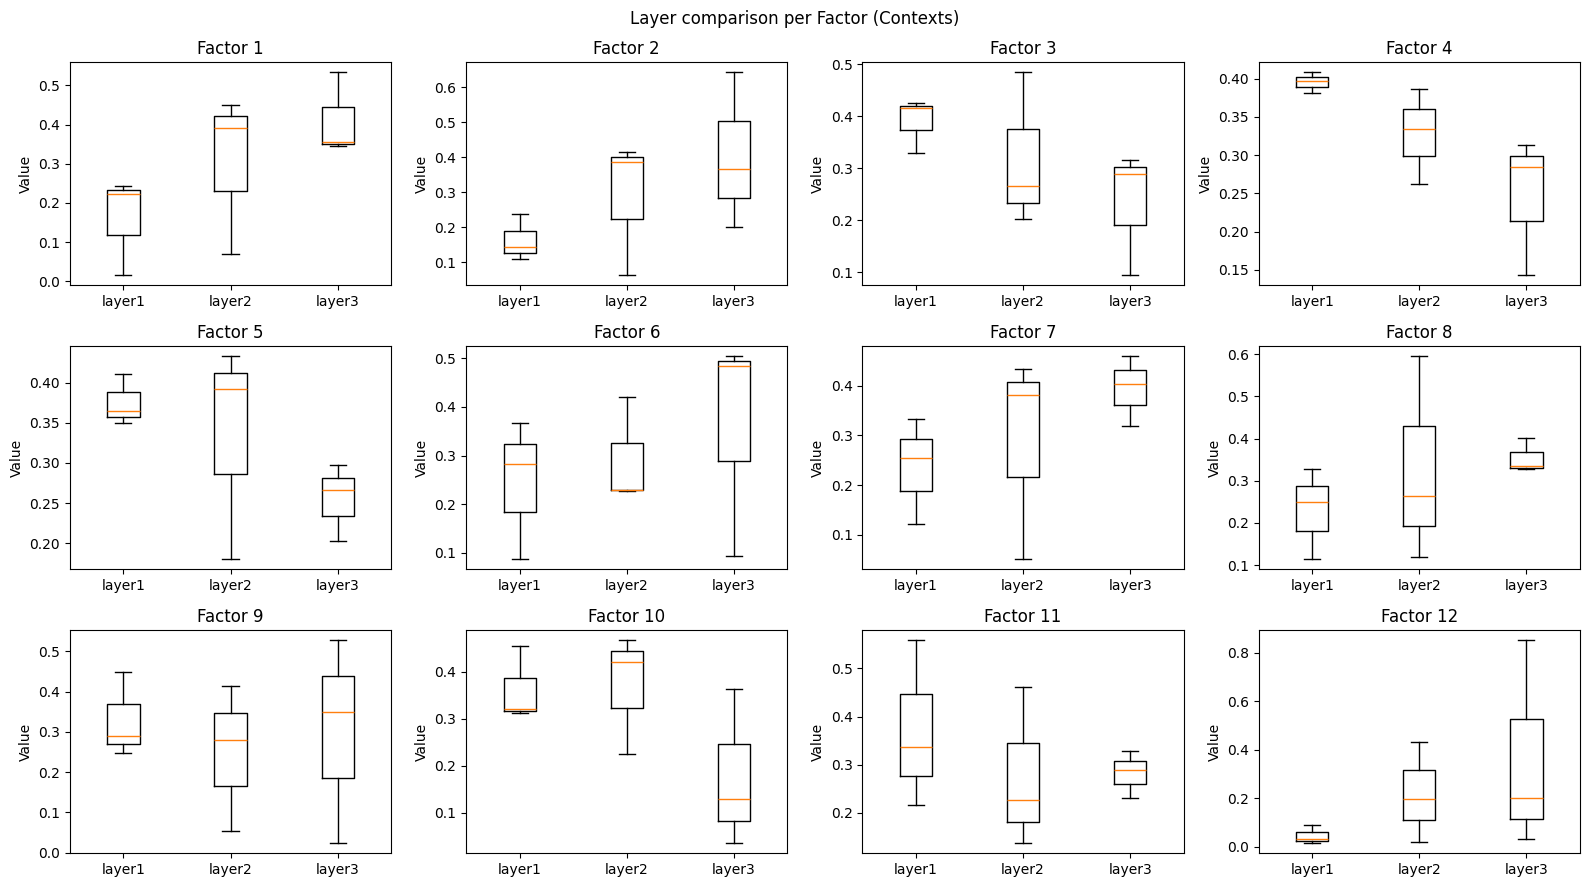

In [35]:
df = factors["Contexts"].copy()
df.index = df.index.astype(str)
df["Layer"] = df.index.str.extract(r'^(layer\d+)', expand=False)

factor_cols = [c for c in df.columns if c != "Layer"]
layers = ["layer1", "layer2", "layer3"]

n = len(factor_cols)
ncol = 4
nrow = math.ceil(n / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*4, nrow*3), sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, factor_cols):
    data = [df.loc[df["Layer"] == L, col].values for L in layers]
    ax.boxplot(data, labels=layers)
    ax.set_title(col)
    ax.set_ylabel("Value")

for ax in axes[len(factor_cols):]:
    ax.set_visible(False)

fig.suptitle("Layer comparison per Factor (Contexts)")
plt.tight_layout()
plt.show()

 <span style="color:red; font-weight:bold">Task 6. Given our biological context, what factors would you be most interested in exploring? </span>

In [ ]:
networks = c2c.analysis.tensor_downstream.get_factor_specific_ccc_networks(factors, 
                                                                           sender_label='Sender Cells',
                                                                           receiver_label='Receiver Cells')
network_by_factors = c2c.analysis.tensor_downstream.flatten_factor_ccc_networks(networks, orderby='receivers')
_ = plt.hist(network_by_factors.values.flatten(), bins = 50)

In [ ]:
ccc_threshold = 0.15

In [ ]:
c2c.plotting.ccc_networks_plot(factors,
                               included_factors=['Factor 4', 'Factor 7', 'Factor 12'],
                               ccc_threshold=ccc_threshold, # Only important communication
                               nrows=1,
                               panel_size=(16, 16), # This changes the size of each figure panel.
                              )

In [ ]:
lr_cm = c2c.plotting.loading_clustermap(factors['Ligand-Receptor Pairs'],
                                        loading_threshold=0.15, # To consider only top LRs
                                        use_zscore=True,
                                        figsize=(16, 9),
                                       )